<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>Data analysis (Python)-  homework for week 12</B></font></td></tr></table>

tips 
- rename the name jupyter notebook file following the rules: **replace ID and name with your student ID and your own name**

In [1]:
name = input("what is your name: ")

what is your name: 1


In [2]:
student_ID = input("what is your student ID: ")

what is your student ID: 1


# 1 mini-batch gradient descent (100 points)
In the section of build and tarin a model, we train the model with stochastic gradient descent and batch gradient descent. In our homework, please train the model using mini-batch gradient descent.  I advise you develop the algorithms in the following steps: 
1. set batch size = 10
2. counts = len(y)
3. initialize theta = np.random.randn(2,1)
4. set learning rate eta = 0.01
4. train the model n_batches times using randomly sampled mini_batches. 

    for loop n_batches times:
        sample one mini batch from X_b and y in each loop ####
        computed gradient with the mini batch in this loop
        update the parameters using gradient descent algorithm with this gradient      

how to sample one mini batch? I list some method you can try
- [choice](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.random.choice.html#numpy.random.choice): randomly get index, and then get the sample using the selected indexs.
- [numpy.random.permutation](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.random.permutation.html):Randomly permute a sequence, or return a permuted range. please get index, and then get the sample using the selected indexs.

# 2 基础版本

In [3]:
# prepare the data
import numpy as np
import pandas as pd

def load_data():
    gdp_satisfaction = pd.read_csv("gdp_satisfaction.csv",index_col = "Country") ###首先读取数据
    X = gdp_satisfaction.values[:,0]
    y = gdp_satisfaction.values[:,1]
    return gdp_satisfaction,X,y

data,X,y = load_data()
X = np.log10(X)
X = X[:,np.newaxis]
y = y[:,np.newaxis]
X_b = np.c_[np.ones((len(X), 1)), X]  

# add x0 = 1 to each instance 
# 对照教学资料，添加一个1 

X_b 

array([[1.        , 3.95688433],
       [1.        , 3.97485107],
       [1.        , 4.08777766],
       [1.        , 4.09674787],
       [1.        , 4.20389561],
       [1.        , 4.23774684],
       [1.        , 4.25682085],
       [1.        , 4.28152405],
       [1.        , 4.3166513 ],
       [1.        , 4.4127078 ],
       [1.        , 4.43449221],
       [1.        , 4.47518551],
       [1.        , 4.51169016],
       [1.        , 4.54830754],
       [1.        , 4.56872832],
       [1.        , 4.57605333],
       [1.        , 4.60321619],
       [1.        , 4.6127469 ],
       [1.        , 4.62298023],
       [1.        , 4.63680834],
       [1.        , 4.63951752],
       [1.        , 4.64072019],
       [1.        , 4.64118337],
       [1.        , 4.69780685],
       [1.        , 4.7063301 ],
       [1.        , 4.70724531],
       [1.        , 4.71054674],
       [1.        , 4.71695578],
       [1.        , 4.7466747 ]])

In [4]:
batch_size = 10
counts = len(y)
n_batchs = 100000
eta = 0.01
theta = np.random.randn(2,1) #随机初始化参数

# please start coding here 

for iteration in range(n_batchs):
    
    index = np.random.choice(counts,batch_size) # 每次抽取一个批次  batch size
    
    mini_batch_X_b = X_b[index] # index 作为一个切片 切出 X
    
    mini_batch_y = y[index] # index 作为一个切片 切出 y

    gradients = 2/batch_size * mini_batch_X_b.T.dot(mini_batch_X_b.dot(theta)-mini_batch_y) # 课堂内容中的公式
    
    theta = theta - eta * gradients


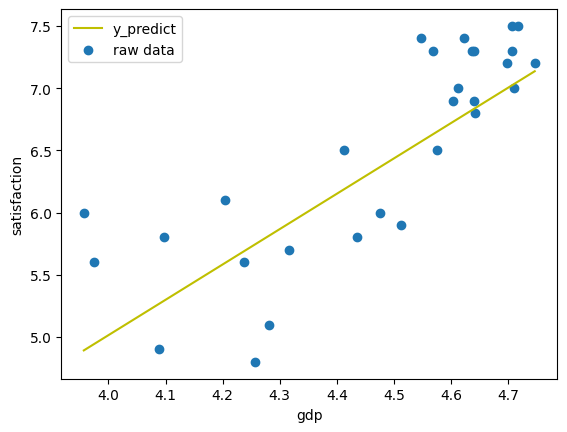

In [5]:
# test your training results

import matplotlib.pyplot as plt
y_predict_gradient = X_b.dot(theta)
plt.plot(X,y_predict_gradient, "y",label = "y_predict")
plt.scatter(X,y,label = "raw data")
plt.xlabel("gdp")
plt.ylabel("satisfaction")
plt.legend()
plt.savefig("gdp_gradient.png")
plt.show()

# 2 改进版本（epoch的概念在文献中可能遇到，便于阅读其他论文）

## 注意：如果要保证想要的样本都拿过来使用了

In [6]:
import random 

In [7]:
def load_batchs(data_x,data_y,batch_size = 10):
    
    counts = len(y)
    
    indices = list(range(counts)) # 样本的个数
    
    random.shuffle(indices) # 首先，将样本的读取顺序随机的（每次都会打乱）
    
    batchs = []
    
    num_batchs = int(counts/batch_size)+1 # 计算下有多少个batch，注意：没有余数的话就不需要+1了，判断是不是整除
    
    
    
    for b in range(num_batchs): ### 每个batch 从头开始取
        
        start = b * batch_size
        
        end = min(start + batch_size,counts) ## 使用min方法，如果取到最后 没有 batch size 那么大，依然取出来
        
        batch_index = index[start:end]
        
        batchs.append((data_x[batch_index],data_y[batch_index])) ##放到元组里面
        
    return batchs

In [8]:
batch_size = 10
counts = len(y)
epoch_num = 100000  # 一期 或一轮 的概念，所有的样本全部应用一边，这里使用 10000遍样本
eta = 0.01
theta = np.random.randn(2,1)

# please start coding here

for epoch in range(epoch_num):
    
    for mini_batch_X_b,mini_batch_y in load_batchs(data_x=X_b,data_y=y,batch_size= 10):
        
        gradients = 2/batch_size * mini_batch_X_b.T.dot(mini_batch_X_b.dot(theta)-mini_batch_y) # 课堂内容中的公式
        theta = theta - eta * gradients

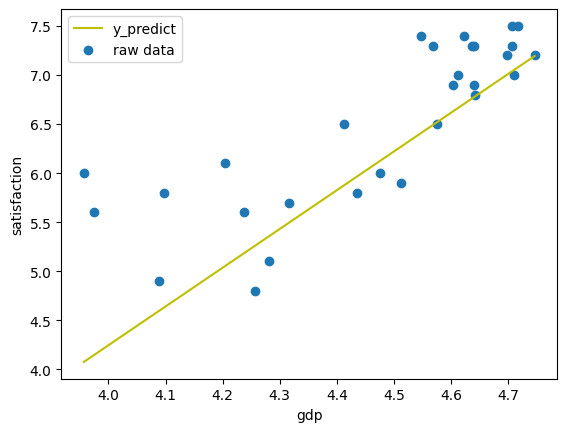

In [9]:
# test your training results
import matplotlib.pyplot as plt
y_predict_gradient = X_b.dot(theta)
plt.plot(X,y_predict_gradient, "y",label = "y_predict")
plt.scatter(X,y,label = "raw data")
plt.xlabel("gdp")
plt.ylabel("satisfaction")
plt.legend()
plt.savefig("gdp_gradient.png")
plt.show()